In [45]:
import pandas as pd
import numpy as np

In [46]:
df_cat= pd.DataFrame(data=[[np.nan, np.nan, np.nan, 0],
                           ['green','M','class1',10],
                           ['blue','L','class2',20],
                           ['white','M','class1',30]],
                           index=['A', 'B', 'C', 'D'])
df_cat.columns=['color','size','classlabel','price']

In [47]:
print(df_cat)

   color size classlabel  price
A    NaN  NaN        NaN      0
B  green    M     class1     10
C   blue    L     class2     20
D  white    M     class1     30


In [48]:
df_cat.info()
print(df_cat.head(2))

print(df_cat.iloc[0])
print(df_cat.iloc[1])
print(df_cat.loc['A'])
print(df_cat.loc['B'])

print(df_cat['color'])
dir(df_cat)

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, A to D
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   color       3 non-null      object
 1   size        3 non-null      object
 2   classlabel  3 non-null      object
 3   price       4 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 160.0+ bytes
   color size classlabel  price
A    NaN  NaN        NaN      0
B  green    M     class1     10
color         NaN
size          NaN
classlabel    NaN
price           0
Name: A, dtype: object
color          green
size               M
classlabel    class1
price             10
Name: B, dtype: object
color         NaN
size          NaN
classlabel    NaN
price           0
Name: A, dtype: object
color          green
size               M
classlabel    class1
price             10
Name: B, dtype: object
A      NaN
B    green
C     blue
D    white
Name: color, dtype: object


['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_REVERSED',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex

### 3 From raw data and pre-processing to data set

In order to be a data scientist you need data. In fact, as a data scientist you will spend an embarrassingly large fraction of your time acquiring and cleaning (for more details, read *Data Science for Scratch*, chap 9–10 written by Joel Grus).

Since learning algorithms are only applied to $(x, y)$ vectors, we need to transform $(u, v) \in \mathcal{U} \times \mathcal{V}$ into vectors using embeddings. Typically a data $u$ is a tuple, or list, $u = (u_1, \cdots, u_n)$. Each component (or field) of $u$ has a type, e.g., real number, Boolean, categorical, ordinal, word, text, audio, image, parse tree.

We consider with feature maps $\phi : \mathcal{U} \times \mathcal{V} \to \mathbb{R}^d$ that transform data into vectors (used as input/output data for the machine learning algorithm). Feature maps usually work on each field separately,

$$
\phi(u_1, \cdots, u_r, v_1, \cdots, v_l) = (\phi_1(u_1), \cdots, \phi_r(u_r), \phi_{r+1}(v_1), \cdots, \phi_{r+l}(v_l)).
$$

$\phi_i$ is an embedding of the type of field $i$ into a vector. The choice of $\phi$ can directly affect the ability of our model to learn; therefore, it is extremely important that we preprocess our data before feeding it into our model.

In the example of Section 2, $\mathcal{U} = \{\text{all the colors}\} \times \{\text{all the sizes}\} \times \{\text{all the class labels}\}$ and $\mathcal{V} = \mathbb{R}$.
Moreover, $r = 3$ and $l = 1$. We give here some simple embeddings and pre-processing techniques:

- For a number input $u \in \mathcal{U} = \mathbb{R}$, $\phi(u) = u$



In [49]:
df_cat['price']

A     0
B    10
C    20
D    30
Name: price, dtype: int64

Handling Null Values : in any real-world dataset, there are always few null values. It doesn’t
really matter whether it is a regression, classification or any other kind of problem, no model
can handle these NULL or NaN values on its own so we need to intervene.

In [50]:
df=df_cat.fillna(0)
print(df)
print(df_cat)

df_cat.fillna(0, inplace=True)
print(df_cat)

   color size classlabel  price
A      0    0          0      0
B  green    M     class1     10
C   blue    L     class2     20
D  white    M     class1     30
   color size classlabel  price
A    NaN  NaN        NaN      0
B  green    M     class1     10
C   blue    L     class2     20
D  white    M     class1     30
   color size classlabel  price
A      0    0          0      0
B  green    M     class1     10
C   blue    L     class2     20
D  white    M     class1     30


In [51]:
df_cat.drop(['A'], inplace= True)

In [52]:
print(df_cat)

   color size classlabel  price
B  green    M     class1     10
C   blue    L     class2     20
D  white    M     class1     30


Handling Categorical Variables. Categorical variables are basically the variables that are
discrete and not continuous. Ex: color of an item is a discrete variable whereas its price is a
continuous variable.
{ Ordinal categorical variables : these variables can be ordered. Example : Size of a
T-shirt. We can say that $ M < L < XL $

In [53]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

In [54]:
size_mapping = {'M': 1, 'L': 2}
type(size_mapping) 

size_mapping['M']

T = size_mapping.get('T', 0)  
len (size_mapping)

size_mapping['S'] = 0
len (size_mapping)

df_cat['size'] = df_cat['size'].map(size_mapping)

class_le = LabelEncoder()
df_cat['classlabel'] = class_le.fit_transform(df_cat['classlabel'].values)

print(df_cat)

   color  size  classlabel  price
B  green     1           0     10
C   blue     2           1     20
D  white     1           0     30


- Nominal categorical variables : if you use the same map() function or LabelEncoder
with nominal variables then the model will think that there is some sort of relationship
between the nominal CVs. For instance, if we use map() to map the colors like

In [55]:
col_mapping = { 'blue' : 1 , 'green' : 2 }

then according to the model, $ Green > Blue $, which is a senseless assumption and the
model will give you results considering this relationship. The correct way of handling
nominal CVs is to use One-Hot Encoding. The easiest way to use One-Hot Encoding is
to use the  get_dummies() function

In [61]:
df_cat = pd.DataFrame({
    'color': ['green', 'blue', 'white'],
    'size': [1.0, 2.0, 1.0],
    'classlabel': [0, 1, 0],
    'price': [10, 20, 30]
})

df_cat = pd.get_dummies(df_cat[['color', 'size', 'classlabel', 'price']])

print(df_cat)

   size  classlabel  price  color_blue  color_green  color_white
0   1.0           0     10           0            1            0
1   2.0           1     20           1            0            0
2   1.0           0     30           0            0            1


In [65]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

for index, mot in enumerate(df_cat.columns):
    X = std.fit_transform(df_cat[mot].values.reshape(-1, 1))
    del df_cat[mot]
    df_cat.insert(index, mot, X)

print(df_cat)


       size  classlabel     price  color_blue  color_green  color_white
0 -0.707107   -0.707107 -1.224745   -0.707107     1.414214    -0.707107
1  1.414214    1.414214  0.000000    1.414214    -0.707107    -0.707107
2 -0.707107   -0.707107  1.224745   -0.707107    -0.707107     1.414214


# 4- Visualization


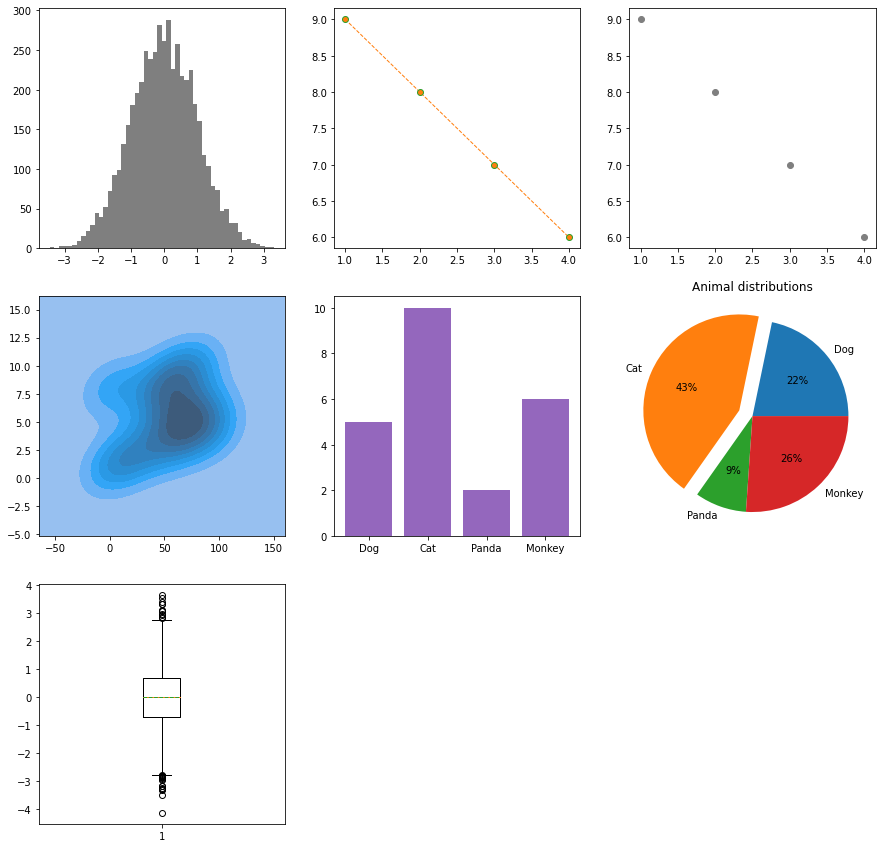

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(3, 3)
fig.set_size_inches(15, 15)
style = dict(color='C1', linewidth=1, linestyle='--', marker='o', mec='C2')

data1, data2 = np.random.randn(2, 5000)
data3 = pd.DataFrame({'Column1': [1, 2, 3, 4], 'Column2': [9, 8, 7, 6]})

axes[0, 0].hist(data1, color='C7', bins=50)

axes[0, 1].plot(data3.Column1, data3.Column2, **style)

axes[0, 2].scatter(data3.Column1, data3.Column2, color='C7')

sns.kdeplot(
    x=[1, 23, 58, 94, 67, 81, 46, 2, 54, 76],
    y=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    fill=True,
    thresh=0,
    ax=axes[1, 0]
)

axes[1, 1].bar(['Dog', 'Cat', 'Panda', 'Monkey'], [5, 10, 2, 6], color='C4')

axes[1, 2].pie(
    [5, 10, 2, 6],
    labels=['Dog', 'Cat', 'Panda', 'Monkey'],
    autopct='%1.0f%%',
    explode=(0.0, 0.15, 0.0, 0.0)
)
axes[1, 2].set_title('Animal distributions')

axes[2, 0].boxplot(data2, showmeans=True, meanline=True)

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

plt.show()


# 5 Splitting data set : train, validation, test


In [69]:
import numpy as np
from sklearn.model_selection import train_test_split

X, y = np.arange(10).reshape((5, 2)), range(5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print('X =', X)
print('y =', list(y))
print('X_train =', X_train)
print('X_test =', X_test)



X = [[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
y = [0, 1, 2, 3, 4]
X_train = [[4 5]
 [0 1]
 [6 7]]
X_test = [[2 3]
 [8 9]]


In [70]:
print ( 'y_train=' , y_train )
print ( 'y_test=', y_test )

y_train= [2, 0, 3]
y_test= [1, 4]
